In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from hnet.models.HyperNet import HyperNet
from hnet.models.MLP import MLP
from hnet.synth import generate
from hnet.synth import utils
from hnet.train.hnet import train_hnet, EnergyDistanceLoss

%load_ext autoreload
%autoreload 2

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using {device}")

Using cuda


# Multimodal prediction

A task that typical ML models struggle with is predicting multimodal functions, for instance any model trained with MSE will collapse to function averages. Using EDL, we show that hypernetworks can effectively predict multimodal functions, offering expanding utility. 

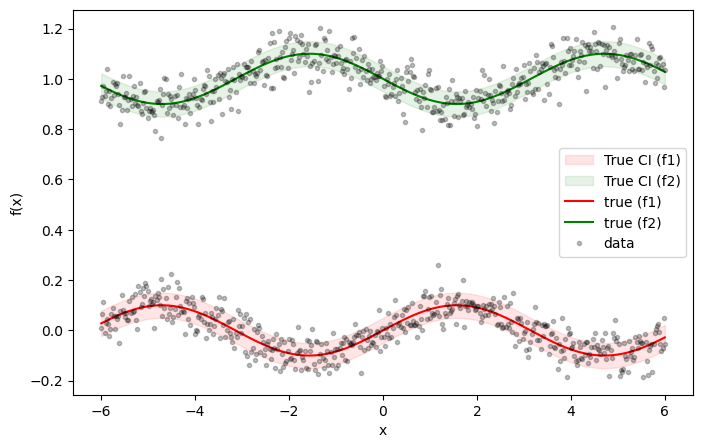

In [27]:
x, y, x_part, y_true_1, y_true_2, true_lcb1, true_ucb1, true_lcb2, true_ucb2 = generate.simple1d_addition(scale=0.05)


utils.plot1d_addition(x,y, x_part, y_true_1, y_true_2, true_lcb1, true_ucb1, true_lcb2, true_ucb2, 
                    title='', plot_ci=True, ylim=None)

In [31]:
num_epochs = 200
nsamples = 250
batch_size = 250
lr = 5e-5
hidden_channels = 32
layers = 2
stochastic_channels = 8
width = 128
use_compile = False
pz = 'bernoulli'

training on cuda


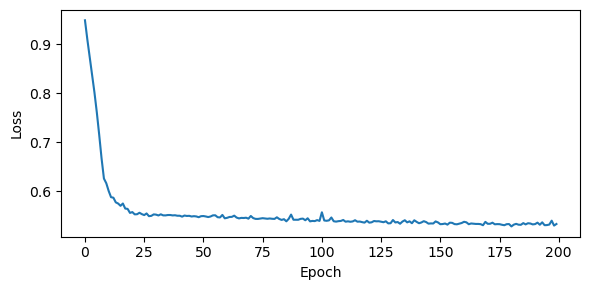

In [32]:
# NOTE: for multimodal prediction we use Energy Distance Loss (edl), closely related to Cramer-Wold distance.
# Standard MSE would collapse to the mean of the modes.
model, losses = train_hnet(
    x.view(-1, 1), y.view(-1, 1),
    mlp_kwargs={'hidden_channels': hidden_channels, 'layers': layers, 'nonlin': 'elu', 'dropout': 0., 'norm': 'layer'},
    hnet_kwargs={'stochastic_channels': stochastic_channels, 'width': width, 'pz': pz},
    loss_fn='edl', lr=lr, batch_size=batch_size, num_epochs=num_epochs, nsamples=nsamples,
    compile=use_compile, use_cuda=(device == 'cuda')
)

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

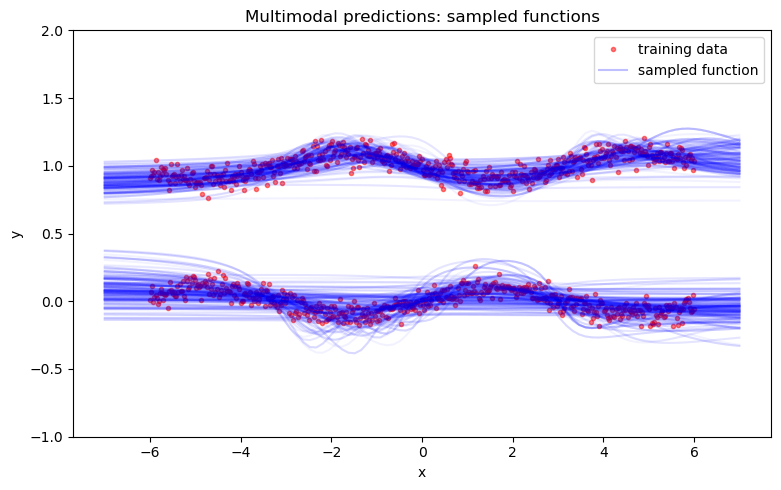

In [34]:
x_plot = torch.linspace(-7, 7, 100)
model.eval()
with torch.no_grad():
    yhat = model(x_plot.unsqueeze(1), samples=500)

plt.figure(figsize=(8, 5))
plt.plot(x.squeeze().numpy(), y.squeeze().numpy(), 'r.', label='training data', alpha=0.5)
x_plot_np = x_plot.detach().cpu().numpy()
first = True
for yyhat in yhat.detach().cpu().numpy():
    yy = yyhat.squeeze()
    if first:
        plt.plot(x_plot_np, yy, 'b-', alpha=0.25, label='sampled function')
        first = False
    else:
        plt.plot(x_plot_np, yy, 'b-', alpha=0.05)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Multimodal predictions: sampled functions')
plt.tight_layout()
plt.ylim(-1, 2)
plt.show()